# Calculating hosting capacity for PG&E, Alameda County

Use the hosting capacity calculation methodology from Brockway et al (2021) to calculate the hosting capacity for PG&E at the feederline level.

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt

In [2]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [3]:
# set option to see all data frame columns
pd.set_option('display.max_columns', None)

## Read in Data

### PG&E Utility

In [4]:
# read in feederline data
pge_circuits = gpd.read_file("../../../../../capstone/electrigrid/data/utilities/pge_shapefiles/LineDetail.shp").to_crs("EPSG:4326")

# load in shapefile for extent of PG&E
utility_ter = gpd.read_file("../../../../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson")

#### Convert `GenCapacit` to MW 

It is currently in KW. We convert in order to standardize to the units of the other two utilities (SDG&E and SCE).

In [5]:
pge_circuits['GenCapacit'] = pge_circuits['GenCapacit'] / 1000
pge_circuits['GenCapac_1'] = pge_circuits['GenCapac_1'] / 1000

#### Brief Exploration

Operational flex allows grid operators to better manage variability and therefore commit more capacity. 

The column that we think is **generation capacity without operational flex** (reverse flow *is* allowed).

In [6]:
pge_circuits['GenCapacit'].describe()

count    731431.000000
mean          0.158990
std           0.489089
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.702000
Name: GenCapacit, dtype: float64

<Axes: ylabel='Frequency'>

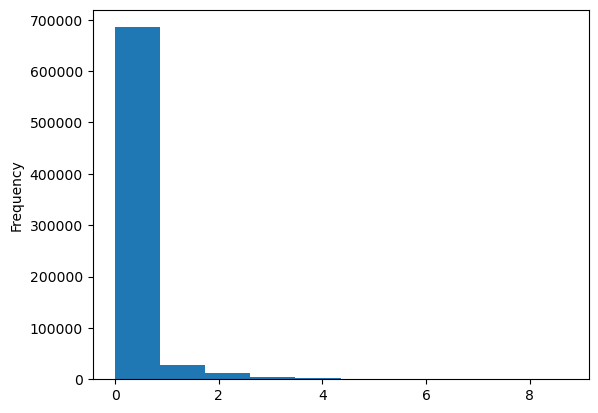

In [7]:
pge_circuits['GenCapacit'].plot(kind = "hist")

The column we think is **generation capacity with operational flex** (reverse flow *is not* allowed).

In [8]:
pge_circuits['GenCapac_1'].describe()

count    731431.000000
mean          0.510265
std           1.396943
min           0.000000
25%           0.000000
50%           0.000000
75%           0.190000
max          20.000000
Name: GenCapac_1, dtype: float64

<Axes: ylabel='Frequency'>

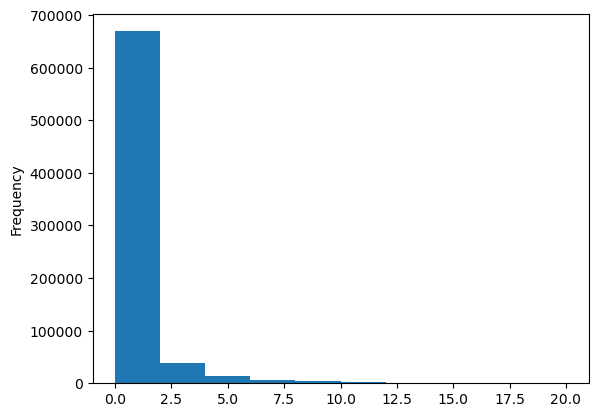

In [9]:
pge_circuits['GenCapac_1'].plot(kind = "hist")

**Findings:** `GenCapac_1` has lower generation capacity values by a magnitude of 100.

#### Change column names to match other utilites

In [11]:
pge_circuits = pge_circuits.rename(columns = {'FeederId':'circuit_id',
                                              'CSV_LineSe':'segment_id'})

In [12]:
pge_circuits.head()

,circuit_id,FeederName,globalid,segment_id,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,geometry
0,062541102,MERIDIAN 1102,{3F991049-BA44-489F-A403-DA79E95B5F6A},3862041,0,12.0,3,None,None,May 2024,May 2024,Sacramento,0.00,0,0.00,0,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,145.642120,"LINESTRING (-121.95921 39.12370, -121.95951 39..."
1,043302102,MONROE 2102,{65E86C65-2474-4DE9-831A-73C5C6C88469},5458148,2380,21.0,3,None,None,Feb 2025,Feb 2025,Sonoma,0.06,70,2.44,2440,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.102052,"LINESTRING (-122.73809 38.48070, -122.73809 38..."
2,063172101,MADISON 2101,{26A0B689-C08B-4AE6-AAC1-341797C5AC4E},3180180,0,21.0,3,None,None,Dec 2024,Dec 2024,Sacramento,0.00,0,0.00,0,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,4.571886,"LINESTRING (-122.01719 38.69234, -122.01714 38..."
3,162701707,VIERRA 1707,{9B295D61-2151-4336-8039-C935C669DD4D},5317517,420,17.0,3,None,None,May 2025,May 2025,Stockton,0.00,0,0.00,0,None,None,None,None,None,None,None,None,Unlikely to pass,1,2025-06-02,47.831056,"LINESTRING (-121.24696 37.75509, -121.24642 37..."
4,254691101,NORCO 1101,{3E99B378-0FDD-4ABD-8D12-6FB6E3E30909},5041662,0,12.0,3,None,None,Apr 2025,Apr 2025,Kern,0.00,0,0.00,0,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,11.245946,"LINESTRING (-119.21527 35.29618, -119.21527 35..."


### Building

In [13]:
# read in multifamily data
alameda_multifamily = gpd.read_file("../../../../../capstone/electrigrid/data/building_zillow_merges/alamedacounty_building_zillow_merge/multi_summed_units_alameda.geojson").set_crs("EPSG:4326")

# read in the single family data  
alameda_singlefamily = gpd.read_file("../../../../../capstone/electrigrid/data/building_zillow_merges/alamedacounty_building_zillow_merge/non_multi_zillow_alameda.geojson").set_crs("EPSG:4326")

We are currently operating with data just for Alameda County, which is under PG&E's jurisdiction. Therefore, instead of clipping to PG&E territory we will clip to the county, rendering the PG&E extent shapefile unnecessary (but only for now!).

#### Clip PG&E utility data to Alameda county

In [14]:
# create bounding box from building data (which is already clipped to Alameda)
alameda_county_box = box(*alameda_singlefamily.total_bounds)

# clip circuits to that bounding box
pge_alameda = gpd.clip(pge_circuits, alameda_county_box)

### Census

In [15]:
# read in the census tract data
census_tracts = gpd.read_file("../../../../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp").to_crs("EPSG:4326")

#### Clip census tracts to Alameda county

In [16]:
census_alameda = gpd.clip(census_tracts, alameda_county_box)

## Preview data

Multi- and single-family homes in blue, feederlines in green, and census tract delineations in gray.

<Axes: >

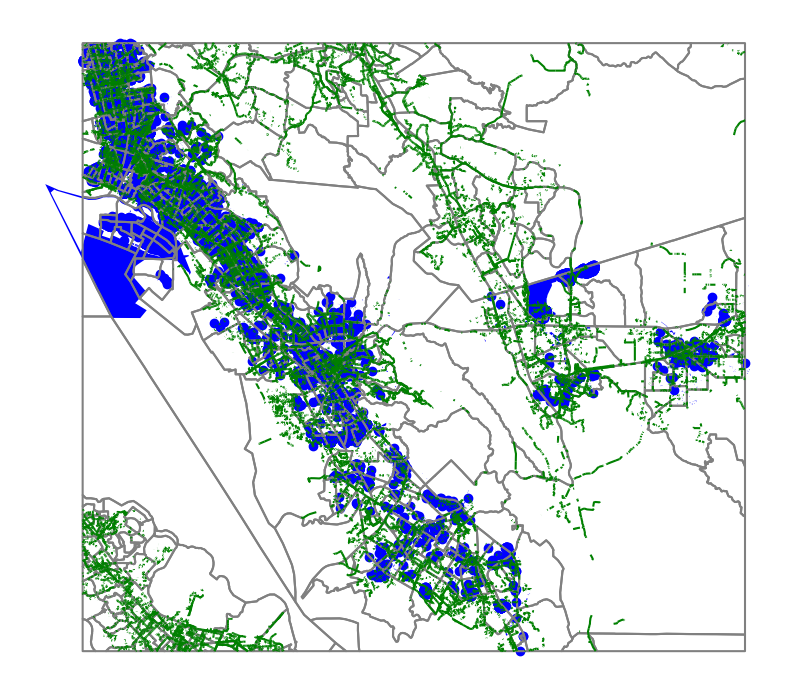

In [17]:
# plot all of the data sources to ensure everything looks accurate 
fig, ax = plt.subplots(figsize=(10, 10))

ax.axis('off')

census_alameda.boundary.plot(ax=ax, 
                    color='gray')

alameda_singlefamily.plot(ax=ax, 
                    color='blue')

alameda_multifamily.plot(ax=ax, 
                    color='blue')

pge_alameda.plot(ax=ax, 
                      color='green')

## Link Buildings to Feederlines

### Adding length column

Before joining the data frames and replacing the feederline geometries with those of the building, we will calculate the length of the lines and bring them over as a column in the join.

In [18]:
# change the crs to a projected CRS
pge_alameda = pge_alameda.to_crs("EPSG:3310")
alameda_singlefamily = alameda_singlefamily.to_crs("EPSG:3310")

In [19]:
## create length column in metres
# single family
pge_alameda['length_m'] = pge_alameda.length

# multi family
alameda_multifamily['length_m'] = alameda_multifamily.length

/tmp/ipykernel_1540524/2118251182.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  alameda_multifamily['length_m'] = alameda_multifamily.length


In [20]:
alameda_singlefamily.head()

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,index_right,source,id,height_m,var,region,bbox,area_m2,volume_m3,geometry
0,Multi,2000.0,1.0,None,None,None,40.0,499500.0,living,840.0,403,06001403302,468,PGE/SCE,RR106,2833938,osm,105058335,14.178774,11.995655,USA,"{'xmin': -122.27082929999999, 'ymin': 37.79499...",1424.845227,20202.558291,POINT (-199644.077 -22194.925)
1,Multi,1976.0,2.0,None,None,O,53.0,1143597.0,living,1364.0,404,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532)
2,Multi,1976.0,2.0,None,None,O,53.0,831707.0,living,1202.0,405,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532)
3,Multi,1976.0,2.0,None,None,None,53.0,1064863.0,living,1349.0,406,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532)
4,Multi,1976.0,2.0,None,None,None,53.0,1150000.0,living,1309.0,407,06001403302,468,PGE/SCE,RR106,2833928,osm,350754536,13.578455,5.557640,USA,"{'xmin': -122.2703524, 'ymin': 37.794816499999...",1351.261163,18348.038855,POINT (-199582.109 -22211.532)


#### Single-family homes

In [21]:
# index the data
pge_alameda.sindex
alameda_singlefamily.sindex

# spatial join
alameda_singlefamily_linked = gpd.sjoin_nearest(alameda_singlefamily, 
                                        pge_alameda, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

#### Multi-family homes

In [22]:
alameda_multifamily = alameda_multifamily.to_crs("EPSG:3310")

# index the data
alameda_multifamily.sindex

# spatial join
alameda_multifamily_linked = gpd.sjoin_nearest(alameda_multifamily, 
                                        pge_alameda, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

### Filter for homes that are less than 1000m away from the nearest feederline
If they are more than 1 km away, we assume they get their power from a different source.

In [23]:
# single family
alameda_singlefamily_linked = alameda_singlefamily_linked[alameda_singlefamily_linked['dist_to_line_m'] >= 1000]

# multi family
alameda_multifamily_linked = alameda_multifamily_linked[alameda_multifamily_linked['dist_to_line_m'] >= 1000]

## Hosting Capacity Calculation

### Step 1: Create length column

Completed before link!

**Note:** `SHAPE_Leng` is the "GIS-provided" length, which is often in decimal degrees – this is why the two columns don't match.

### Step 2: Add census tract ID to each home

In [24]:
## single family join

# change CRS so it matches
alameda_singlefamily_linked = alameda_singlefamily_linked.to_crs("EPSG:4326")

assert alameda_singlefamily_linked.crs == census_alameda.crs

# drop columns that makes joins impossible
alameda_singlefamily_linked = alameda_singlefamily_linked.drop(['index_right'], axis = 1)

# join
alameda_singlefamily_linked = alameda_singlefamily_linked.sjoin(
    census_alameda,
    how = "left",
    predicate = "intersects")

## multi family join   

# change CRS so it matches
alameda_multifamily_linked = alameda_multifamily_linked.to_crs("EPSG:4326")

assert alameda_multifamily_linked.crs == census_alameda.crs

# drop columns that makes joins impossible
#alameda_multifamily_linked = alameda_multifamily_linked.drop(['index_right'], axis = 1)

# single family join
alameda_multifamily_linked = alameda_multifamily_linked.sjoin(
    census_alameda,
    how = "left",
    predicate = "intersects")

In [25]:
alameda_singlefamily_linked.head(2)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID_left,p_ID,area,code,source,id,height_m,var,region,bbox,area_m2,volume_m3,geometry,index__right,circuit_id,FeederName,globalid,segment_id,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,length_m,dist_to_line_m,index_right,STATEFP,COUNTYFP,TRACTCE,GEOID_right,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON
10448,Single,1930.0,3.0,None,None,O,1.0,1265244.0,living,1744.0,265575,06001428100,h1334,Others,RR101,osm,465944669,6.863454,0.569706,USA,"{'xmin': -122.2361823, 'ymin': 37.760694199999...",90.572749,621.641883,POINT (-122.23609 37.76071),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1159.551331,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068
10449,Single,1910.0,2.0,None,None,I,1.0,303551.0,living,1148.0,265590,06001428100,h1334,Others,RR101,osm,465944916,8.449631,1.196003,USA,"{'xmin': -122.2376855, 'ymin': 37.7588378, 'xm...",158.417824,1338.572111,POINT (-122.23756 37.75892),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1393.471538,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068


### Step 3: Calculate the number of homes in each census tract

In [26]:
# calculate the number of observations in each
by_tract = alameda_singlefamily_linked.groupby('GEOID_right').sum('unit')

# save just the unit column and rename to be more intuitive
units_by_tract = by_tract['unit']
units_by_tract = units_by_tract.rename('units_by_tract')

# join units by tract to entire df
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    units_by_tract,
    on = "GEOID_right")

### Step 4: Calculate the maximum ICA generation capacity for each circuit

In [27]:
# find maximum generation across feederline
max_gen = alameda_singlefamily_linked.groupby('circuit_id').max('GenCapacit')

# save just the necessary column and rename
max_gen_feeder = max_gen['GenCapacit'].rename('max_gen')

# join max generation by feeder to entire df
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    max_gen_feeder,
    on = 'circuit_id')

### Step 5: Calculate the percentage of the length of each segment relative to the entire feederline/circuit

In [28]:
# find the total length by Feeder Id
total_length = alameda_singlefamily_linked.groupby('circuit_id').sum('length_m')

# rename
total_length = total_length['length_m'].rename('total_feeder_length')

# join
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    total_length,
    on = 'circuit_id')

In [29]:
# calculate percentage
alameda_singlefamily_linked['perc_length'] = (alameda_singlefamily_linked['length_m'] / alameda_singlefamily_linked['total_feeder_length']) * 100

In [30]:
alameda_singlefamily_linked.head()

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID_left,p_ID,area,code,source,id,height_m,var,region,bbox,area_m2,volume_m3,geometry,index__right,circuit_id,FeederName,globalid,segment_id,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,length_m,dist_to_line_m,index_right,STATEFP,COUNTYFP,TRACTCE,GEOID_right,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,units_by_tract,max_gen,total_feeder_length,perc_length
0,Single,1930.0,3.0,None,None,O,1.0,1265244.0,living,1744.0,265575,06001428100,h1334,Others,RR101,osm,465944669,6.863454,0.569706,USA,"{'xmin': -122.2361823, 'ymin': 37.760694199999...",90.572749,621.641883,POINT (-122.23609 37.76071),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1159.551331,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687
1,Single,1910.0,2.0,None,None,I,1.0,303551.0,living,1148.0,265590,06001428100,h1334,Others,RR101,osm,465944916,8.449631,1.196003,USA,"{'xmin': -122.2376855, 'ymin': 37.7588378, 'xm...",158.417824,1338.572111,POINT (-122.23756 37.75892),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1393.471538,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687
2,Single,1890.0,3.0,None,None,I,1.0,1058000.0,living,2027.0,265603,06001428100,h1334,Others,RR101,osm,465944867,4.386361,0.333628,USA,"{'xmin': -122.2376623, 'ymin': 37.759865800000...",117.902242,517.161753,POINT (-122.23754 37.75993),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1311.136837,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687
3,Single,1940.0,4.0,None,None,O,1.0,323077.0,living,2145.0,265612,06001428100,h1334,Others,RR101,osm,465944896,6.565110,1.180473,USA,"{'xmin': -122.2365514, 'ymin': 37.7598237, 'xm...",148.887508,977.462830,POINT (-122.23648 37.75993),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1246.323898,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687
4,Single,1920.0,2.0,None,None,I,1.0,683254.0,living,1023.0,265624,06001428200,h1334,Others,RR101,osm,466378166,4.072652,2.460497,USA,"{'xmin': -122.23778670000002, 'ymin': 37.75734...",133.078178,541.981155,POINT (-122.23769 37.75741),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1528.920501,1798,06,001,428200,06001428200,1400000US06001428200,4282,Census Tract 4282,G5020,S,1362067,804742,+37.7533497,-122.2396803,78.0,0.67,2271.863779,0.415687


**Note:** Why are there multiple rows with the same `CSV_LineSe`?

### Step 6: Calculate the number of homes connected to each segment

In [31]:
# find the number of homes
home_count_seg = alameda_singlefamily_linked.groupby('segment_id').sum('unit')

# save just the unit columns and rename to be more intuitive
home_count_seg = home_count_seg['unit'].rename('home_count_seg')

# join with original df based on line segment 
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    home_count_seg,
    on = "segment_id")

### Step 7: Calculate the number of homes connected to each circuit

In [32]:
# find the number of homes
home_count_seg = alameda_singlefamily_linked.groupby('circuit_id').sum('unit')

# save just the unit columns and rename to be more intuitive
home_count_seg = home_count_seg['unit'].rename('home_count_circuit')

# join with original df based on line segment 
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    home_count_seg,
    on = "circuit_id")

### Step 8: Calculate the number of homes connected to segment relative to the number of homes connected to entire feederline/circuit

In [33]:
# calculate perc of homes and save as column
alameda_singlefamily_linked['perc_homes'] = (alameda_singlefamily_linked['home_count_seg'] / alameda_singlefamily_linked['home_count_circuit']) * 100

### Step 9: Calculate weighted generation capacity for each segment
Multiply the maximum generation capacity of each circuit by the the percentage of households each segment represents relative to the whole (`perc_homes`). This will undercount the total maximum hosting capacity of each circuit.

### Step 10: Calculate the number of homes located within each census tract for each circuit

**Variable:** # of households within circuit polygon

Circuit polygon definition: corresponds to the overlap between census tract and the estimated service area of circuit

In [34]:
circ_poly = alameda_singlefamily_linked.groupby(['GEOID_right', 'circuit_id']).sum('unit')

circ_poly_units = circ_poly['unit'].rename('tothh_Cpoly')

alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    circ_poly_units,
    on = ['GEOID_right', 'circuit_id'])

### Step 10b: Calculate the max generation within each census tract for each circuit

**Variable:** maximum generation within census tract, by feederline

In [35]:
circ_poly_gen = alameda_singlefamily_linked.groupby(['GEOID_right', 'circuit_id']).max('GenCapacit')

circ_poly_gen_max = circ_poly['GenCapacit'].rename('DER_max_Cpoly')

alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    circ_poly_gen_max,
    on = ['GEOID_right', 'circuit_id'])

### Step 11: Weight by household (complete Equation 8)

**Equation 8 from Brockway et al.**: 

_hhWt = (max capacity across circuit polygon) * (# of households within circuit polygon / # of households served by circuit)

**or**

`_hhWt` = `DER_max_Cpoly` * ( `tothh_Cpoly` / `home_count_circuit` )

In [36]:
# calculate weight by household
alameda_singlefamily_linked['_hhWt'] = alameda_singlefamily_linked['DER_max_Cpoly'] * (alameda_singlefamily_linked['tothh_Cpoly'] / alameda_singlefamily_linked['home_count_circuit'])

**Note:** Values are different for observations with same `CSV_LineSe` but different GEOIDs.

### Step 12: Normalize household weight (complete Equation 9)

**Equation 9 from Brockway et al.:**

_hhWt_n = (household-weight max capacity) * (maximum capacity anywhere on circuit / household-weighted max capacity summed across circuit)

**or**

`_hhWt_n` = `_hhWt` * (`max_gen` / summ j [`_hhWt`] )

In [37]:
# calculate summation of household-weighted max capacity across circuit
summ_hhWt = alameda_singlefamily_linked.groupby('circuit_id').sum('_hhWt')

# save the summed column and rename
summ_hhWt = summ_hhWt['_hhWt'].rename('summ_hhWt')

# add to data frame through join
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    summ_hhWt,
    on = ['circuit_id'])

In [38]:
# equation 9
alameda_singlefamily_linked['_hhWt_n'] = alameda_singlefamily_linked['_hhWt'] * (alameda_singlefamily_linked['max_gen'] / alameda_singlefamily_linked['summ_hhWt'])

### Step 13: Adjust for observations where max capacity is exceeded (complete Equation 10)

"For a small minority of circuit polygons (0.05–1.60%, depending on DER type),
the normalized hosting capacity value exceeds the maximum allowed hosting
capacity in that circuit polygon. In these cases, we adjusted the value back to its
allowed maximum:"

**Equation 10 from Brockway et al.:

_hhWt_n = 

    if _hhWt_n > (max capacity across circuit polygon), then replace with max capacity across circuit polygon,
    else: 
            _hhWt_n
    
**or**

`_hhWt_n` = if `_hhWt_n` > `DER_max_Cpoly`, then `DER_max_Cpoly`,
            else `_hhWt_n`

In [39]:
alameda_singlefamily_linked['_hhWt_n'] = np.where(
    
    # condition -- weighted generation is greater than max generation across circuit/feederline
    alameda_singlefamily_linked['_hhWt_n'] > alameda_singlefamily_linked['DER_max_Cpoly'],
    
    # replace with max generation of feederline if condition is true
    alameda_singlefamily_linked['DER_max_Cpoly'], 
    
    # otherwise, keep original calculated value
    alameda_singlefamily_linked['_hhWt_n'])

**Note:** Could potentially check if this worked by creating a completely new column (instead of just replacing the old one), and seeing how the two compare.

### Step 14: Calculate remaining per-household capacity

**Equation 11 from Brockway et al.:**

`DER_remain`, or kW per household = `_hhWt_n` / `tothh_Cpoly`

In [40]:
alameda_singlefamily_linked['DER_remain'] = alameda_singlefamily_linked['_hhWt_n'] / alameda_singlefamily_linked['tothh_Cpoly'] * 1000

### Step 15: Calculate final per-household hosting capacity

**Equation 12 from Brockway et al.**

`DER` = `DER_exist` + `DER_remain`

In [41]:
alameda_singlefamily_linked_clean = alameda_singlefamily_linked[['ID', 'unit', 'bbox', 'geometry', # columns used in analysis
                                                                        'circuit_id', 'segment_id', 'GenCapacit', 
                                                                        'dist_to_line_m','GEOID_right', 
                                                                        
                                                                        # columns created for analysis
                                                                        'length_m', 'units_by_tract', 'max_gen', 'total_feeder_length', 'perc_length',
                                                                        'home_count_seg', 'home_count_circuit', 'perc_homes',
                                                                        'tothh_Cpoly', 'DER_max_Cpoly', '_hhWt', '_hhWt_n', 'DER_remain']]

In [42]:
alameda_singlefamily_linked_clean.head()

,ID,unit,bbox,geometry,circuit_id,segment_id,GenCapacit,dist_to_line_m,GEOID_right,length_m,units_by_tract,max_gen,total_feeder_length,perc_length,home_count_seg,home_count_circuit,perc_homes,tothh_Cpoly,DER_max_Cpoly,_hhWt,_hhWt_n,DER_remain
0,265575,1.0,"{'xmin': -122.2361823, 'ymin': 37.760694199999...",POINT (-122.23609 37.76071),012091112,3455480,0.67,1159.551331,06001428100,9.443846,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,0.001905,0.020489
1,265590,1.0,"{'xmin': -122.2376855, 'ymin': 37.7588378, 'xm...",POINT (-122.23756 37.75892),012091112,3455480,0.67,1393.471538,06001428100,9.443846,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,0.001905,0.020489
2,265603,1.0,"{'xmin': -122.2376623, 'ymin': 37.759865800000...",POINT (-122.23754 37.75993),012091112,3455480,0.67,1311.136837,06001428100,9.443846,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,0.001905,0.020489
3,265612,1.0,"{'xmin': -122.2365514, 'ymin': 37.7598237, 'xm...",POINT (-122.23648 37.75993),012091112,3455480,0.67,1246.323898,06001428100,9.443846,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,0.001905,0.020489
4,265624,1.0,"{'xmin': -122.23778670000002, 'ymin': 37.75734...",POINT (-122.23769 37.75741),012091112,3455480,0.67,1528.920501,06001428200,9.443846,78.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,75.0,34.09,5.003425,0.002371,0.031619


## GEOID check

In [43]:
alameda_singlefamily_linked['GEOID_right'] == alameda_singlefamily_linked['GEOID_left']

0      True
1      True
2      True
3      True
4      True
       ... 
538    True
539    True
540    True
541    True
542    True
Length: 543, dtype: bool

In [44]:
alameda_singlefamily_linked['GEOID_right'].eq(alameda_singlefamily_linked['GEOID_left']).value_counts()

True    543
Name: count, dtype: int64

In [45]:
alameda_singlefamily_linked.head()

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID_left,p_ID,area,code,source,id,height_m,var,region,bbox,area_m2,volume_m3,geometry,index__right,circuit_id,FeederName,globalid,segment_id,LoadCapaci,voltage_kv,phase_cnt,limiting_m,limiting_c,ICA_Analys,lica_analy,Division,GenCapacit,GenericPVC,GenCapac_1,GenericCap,limiting_1,limiting_2,limiting_3,limiting_4,limiting_5,limiting_6,limiting_7,limiting_8,ScreenL,Publish,Last_Updat,SHAPE_Leng,length_m,dist_to_line_m,index_right,STATEFP,COUNTYFP,TRACTCE,GEOID_right,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,units_by_tract,max_gen,total_feeder_length,perc_length,home_count_seg,home_count_circuit,perc_homes,tothh_Cpoly,DER_max_Cpoly,_hhWt,summ_hhWt,_hhWt_n,DER_remain
0,Single,1930.0,3.0,None,None,O,1.0,1265244.0,living,1744.0,265575,06001428100,h1334,Others,RR101,osm,465944669,6.863454,0.569706,USA,"{'xmin': -122.2361823, 'ymin': 37.760694199999...",90.572749,621.641883,POINT (-122.23609 37.76071),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1159.551331,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,1413.609843,0.001905,0.020489
1,Single,1910.0,2.0,None,None,I,1.0,303551.0,living,1148.0,265590,06001428100,h1334,Others,RR101,osm,465944916,8.449631,1.196003,USA,"{'xmin': -122.2376855, 'ymin': 37.7588378, 'xm...",158.417824,1338.572111,POINT (-122.23756 37.75892),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1393.471538,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,1413.609843,0.001905,0.020489
2,Single,1890.0,3.0,None,None,I,1.0,1058000.0,living,2027.0,265603,06001428100,h1334,Others,RR101,osm,465944867,4.386361,0.333628,USA,"{'xmin': -122.2376623, 'ymin': 37.759865800000...",117.902242,517.161753,POINT (-122.23754 37.75993),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1311.136837,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,1413.609843,0.001905,0.020489
3,Single,1940.0,4.0,None,None,O,1.0,323077.0,living,2145.0,265612,06001428100,h1334,Others,RR101,osm,465944896,6.565110,1.180473,USA,"{'xmin': -122.2365514, 'ymin': 37.7598237, 'xm...",148.887508,977.462830,POINT (-122.23648 37.75993),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06-02,9.440764,9.443846,1246.323898,1797,06,001,428100,06001428100,1400000US06001428100,4281,Census Tract 4281,G5020,S,994804,38328,+37.7589136,-122.2346068,93.0,0.67,2271.863779,0.415687,72.0,511.0,14.09002,93.0,22.09,4.020294,1413.609843,0.001905,0.020489
4,Single,1920.0,2.0,None,None,I,1.0,683254.0,living,1023.0,265624,06001428200,h1334,Others,RR101,osm,466378166,4.072652,2.460497,USA,"{'xmin': -122.23778670000002, 'ymin': 37.75734...",133.078178,541.981155,POINT (-122.23769 37.75741),127486,012091112,OAKLAND J 1112,{83EFB72C-117A-40CF-8D92-CE6DF00A1F67},3455480,0,12.0,3,None,None,May 2025,May 2025,East Bay,0.67,2630,0.67,670,None,None,None,None,None,None,None,None,Likely to pass,1,2025-06

In [46]:
alameda_singlefamily_linked['DER_remain'].describe()

count     521.000000
mean        4.894262
std       111.278587
min         0.000000
25%         0.005493
50%         0.017852
75%         0.021222
max      2540.000000
Name: DER_remain, dtype: float64

<Axes: ylabel='Frequency'>

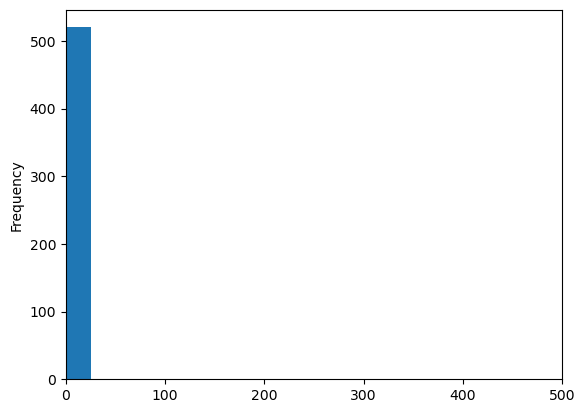

In [47]:
alameda_singlefamily_linked['DER_remain'].plot(kind = "hist",
                                              xlim=(0, 500),
                                              bins=range(0, 500, 25))

**Note:** Without Op Flex, no negatives! 

## Repeat workflow for generation capacity *with* operational flex

Starting with Step 4 --> the first place generation capacity is introduced.

In [48]:
# replicate entire pipeline from above

# Step 4
# find maximum generation across feederline
max_gen = alameda_singlefamily_linked.groupby('circuit_id').max('GenCapac_1')

# save just the necessary column and rename
max_gen_feeder = max_gen['GenCapac_1'].rename('max_gen_opflex')

# join max generation by feeder to entire df
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    max_gen_feeder,
    on = 'circuit_id')

# Step 10b
circ_poly_gen = alameda_singlefamily_linked.groupby(['GEOID_right', 'circuit_id']).max('GenCapac_1')

circ_poly_gen_max = circ_poly['GenCapac_1'].rename('DER_max_Cpoly_opflex')

alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    circ_poly_gen_max,
    on = ['GEOID_right', 'circuit_id'])

# Step 11
# calculate weight by household
alameda_singlefamily_linked['_hhWt_opflex'] = alameda_singlefamily_linked['DER_max_Cpoly_opflex'] * (alameda_singlefamily_linked['tothh_Cpoly'] / alameda_singlefamily_linked['home_count_circuit'])

# Step 12
# calculate summation of household-weighted max capacity across circuit
summ_hhWt = alameda_singlefamily_linked.groupby('circuit_id').sum('_hhWt_opflex')

# save the summed column and rename
summ_hhWt = summ_hhWt['_hhWt_opflex'].rename('summ_hhWt_opflex')

# add to data frame through join
alameda_singlefamily_linked = alameda_singlefamily_linked.merge(
    summ_hhWt,
    on = ['circuit_id'])

# equation 9
alameda_singlefamily_linked['_hhWt_n_opflex'] = alameda_singlefamily_linked['_hhWt_opflex'] * (alameda_singlefamily_linked['max_gen_opflex'] / alameda_singlefamily_linked['summ_hhWt_opflex'])

# Step 13
alameda_singlefamily_linked['_hhWt_n_opflex'] = np.where(
    
    # condition -- weighted generation is greater than max generation across circuit/feederline
    alameda_singlefamily_linked['_hhWt_n_opflex'] > alameda_singlefamily_linked['DER_max_Cpoly_opflex'],
    
    # replace with max generation of feederline if condition is true
    alameda_singlefamily_linked['DER_max_Cpoly_opflex'], 
    
    # otherwise, keep original calculated value
    alameda_singlefamily_linked['_hhWt_n_opflex'])

# Step 14
alameda_singlefamily_linked['DER_remain_opflex'] = alameda_singlefamily_linked['_hhWt_n_opflex'] / alameda_singlefamily_linked['tothh_Cpoly'] * 1000

#### Explore

In [49]:
alameda_singlefamily_linked['DER_remain_opflex'].describe()

count     529.000000
mean       15.074246
std       340.425752
min         0.000610
25%         0.020420
50%         0.031558
75%         0.197437
max      7830.000000
Name: DER_remain_opflex, dtype: float64

In [50]:
alameda_singlefamily_linked['DER_remain'].describe()

count     521.000000
mean        4.894262
std       111.278587
min         0.000000
25%         0.005493
50%         0.017852
75%         0.021222
max      2540.000000
Name: DER_remain, dtype: float64

**With** operational flex appears to have larger generation capacity values, and no negative ones (opposite of the raw exploration we did before...does this make sense?)

<Axes: ylabel='Frequency'>

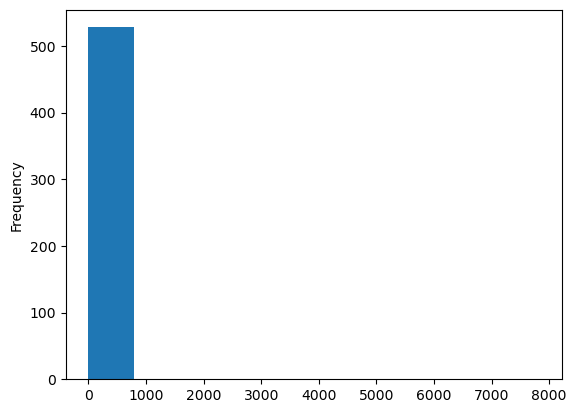

In [51]:
alameda_singlefamily_linked['DER_remain_opflex'].plot(kind = "hist")

minor change